x0,x1,x2
<dbl>,<dbl>,<dbl>
1,13.877842,9.7750351
1,13.817652,-4.5727706
1,7.115517,8.6220865
1,10.053992,-3.5937828
1,6.992723,5.7292168
1,12.846879,5.7665011
1,12.050905,1.6500980
1,11.329444,4.7296777
1,8.112368,-0.5245891


e,y
<dbl>,<dbl>
-3.34631691,62.83728
1.40757096,38.71498
-0.88370163,42.70702
0.23754567,28.21196
-4.01725419,33.41935
1.83898286,56.91262
4.37542959,48.82834
1.05415672,49.50185
6.43943983,34.72737


y,x1,x2
<dbl>,<dbl>,<dbl>
62.83728,13.877842,9.7750351
38.71498,13.817652,-4.5727706
42.70702,7.115517,8.6220865
28.21196,10.053992,-3.5937828
33.41935,6.992723,5.7292168
56.91262,12.846879,5.7665011
48.82834,12.050905,1.6500980
49.50185,11.329444,4.7296777
34.72737,8.112368,-0.5245891


x0,7.2967
x1,2.8127
x2,1.8775


[1] 7.296661

...


Call:
lm(formula = y ~ x1 + x2, data = dt)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.8834 -1.8134 -0.1769  1.5628  9.3952 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  7.29666    0.78048   9.349   <2e-16 ***
x1           2.81267    0.07030  40.011   <2e-16 ***
x2           1.87750    0.05994  31.322   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.81 on 197 degrees of freedom
Multiple R-squared:  0.9194,	Adjusted R-squared:  0.9186 
F-statistic:  1124 on 2 and 197 DF,  p-value: < 2.2e-16



Persamaan regresi (lm): y = 7.297 + 2.813 x1 + 1.877 x2


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
x1,1,9995.769,9995.769290,1266.0233,1.030145e-87
x2,1,7746.099,7746.098911,981.0892,1.937875e-78
Residuals,197,1555.395,7.895407,NA,NA


,2.5 %,97.5 %
(Intercept),5.757501,8.835821
x1,2.674035,2.951297
x2,1.759287,1.995704


,matriks,fungsi lm
intersep,7.296661,7.296661
b1,2.812666,2.812666
b2,1.877495,1.877495


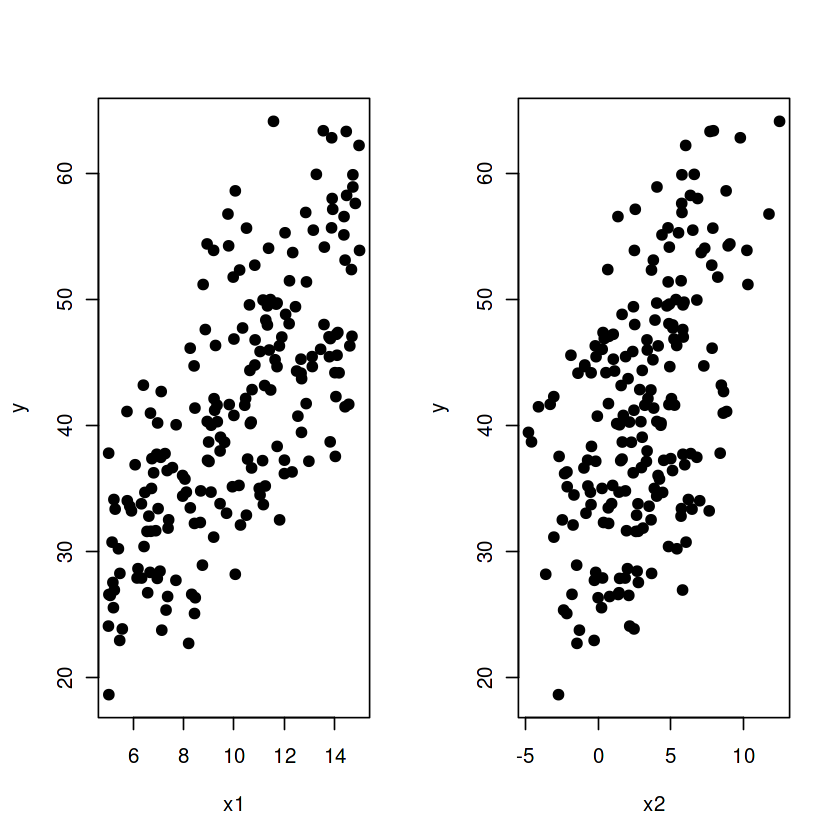

In [3]:
# ===============================
# Praktikum 4 Analisis Regresi
# Muhammad Shira Pramudita
# ===============================

set.seed(2006)
n <- 200
p <- 6

# ===============================
# Bangkitkan Data
# ===============================

x1 <- runif(n,5,15)
x2 <- rnorm(n,3,3)
x0 <- rep(1,n)
X  <- data.frame(x0,x1,x2)
X

e  <- rnorm(n,0,3)
y <- 5 + 3*x1 + 2*x2 + e
rand.comp <- data.frame(e,y)
rand.comp

dt <- data.frame(y,x1,x2)
dt

# ===============================
# Eksplorasi Data
# ===============================

par(mfrow=c(1,2))
plot(x1, y, pch=19)
plot(x2, y, pch=19)

# ===============================
# Model Regresi Dengan Matriks
# ===============================

y <- as.matrix(y)
X <- as.matrix(cbind(x0,x1,x2))
b <- solve(t(X)%*%X)%*%t(X)%*%y
round(b,4)

b0<-b[1];b0
b1<-b[2];b1
b2<-b[3];b2

cat("\nPersamaan regresi: y =", round(b0,3), "+", round(b1,3),"x1 +", round(b2,3),"x2\n")

# ===============================
# Koefisien Determinasi
# ===============================

sigma_kuadrat <- (t(y)%*%y-t(b)%*%t(X)%*%y)/(n-p)
Res_se <- sqrt(sigma_kuadrat)
round(Res_se,3)

df <- n-p
df

y_duga <- b0+b1*x1+b2*x2
Y <- data.frame(y,y_duga)
Y

R_squared <- (cor(y,y_duga))^2
round(R_squared,4)

R_squared_adj <- 1-((1-R_squared)*(n-1)/(n-p))
round(R_squared_adj,4)

# ===============================
# Uji F
# ===============================

KTReg <- sum((y_duga-mean(y))^2)/(p-1)
galat <- y-(b0+b1*x1+b2*x2)
KTG   <- sum(galat^2)/(n-p)
Fhit  <- KTReg/KTG
round(Fhit,0)

dbreg <- p-1
dbg <- n-p

pf(Fhit, dbreg, dbg, lower.tail = FALSE)

# ===============================
# Standar Error Parameter
# ===============================

cov_beta <- sigma_kuadrat[1] * solve(t(X) %*% X)
se_b <- sqrt(diag(cov_beta))
round(se_b,4)

# ===============================
# Uji t
# ===============================

t_b0 <- b0/se_b[1]
round(t_b0,2)
2*pt(-abs(t_b0 ),df <- n-p)

t_b1 <- b1/se_b[2]
round(t_b1,2)
2*pt(-abs(t_b1 ),df <- n-p)

t_b2 <- b2/se_b[3]
round(t_b2,2)
2*pt(-abs(t_b2 ),df <- n-p)

# ===============================
# Selang Kepercayaan 95%
# ===============================

t_val <- qt(.975, df <- n-p)

BB_b0 <- b0-t_val*se_b[1]
BA_b0 <- b0+t_val*se_b[1]

BB_b1 <- b1-t_val*se_b[2]
BA_b1 <- b1+t_val*se_b[2]

BB_b2 <- b2-t_val*se_b[3]
BA_b2 <- b2+t_val*se_b[3]

Batas.Bawah <- as.matrix(c(round(BB_b0,6),
                           round(BB_b1,6),
                           round(BB_b2,6)))

Batas.Atas <- as.matrix(c(round(BA_b0,6),
                          round(BA_b1,6),
                          round(BA_b2,6)))

Selang.Kepercayaan <- cbind(Batas.Bawah, Batas.Atas)
colnames(Selang.Kepercayaan ) <- c("Batas bawah Selang (2.5%)",
                                   "Batas atas Selang (97.5%)")
rownames(Selang.Kepercayaan ) <- c("Intersept", "b1", "b2")
Selang.Kepercayaan

# ===============================
# Model Dengan lm()
# ===============================

model_reg <- lm(y~x1+x2, data= dt)
summary(model_reg)

cat("\nPersamaan regresi (lm): y =",
    round(coef(model_reg)[1],3), "+",
    round(coef(model_reg)[2],3),"x1 +",
    round(coef(model_reg)[3],3),"x2\n")

anova(model_reg)
confint(model_reg, level = 0.95)

# ===============================
# Perbandingan
# ===============================

koef<- as.matrix(model_reg$coefficients)
penduga <- cbind(b, koef)
colnames(penduga) <- c('matriks', 'fungsi lm')
rownames(penduga) <- c("intersep", "b1", "b2")
penduga